
 POLICY COMPLEXITY RESULTS 

|R|:                 26
WSC(R):              89
WSC(R) / |R|:        3.4231
C(R):                1447.3041
C(R) / |R|:          55.665542
C(R) / WSC(R):       16.261844
C(R) / C_max(R):     0.096216
C(R) / C_practical_max(R) 90: 0.268437
C(R) / C_practical_max(R) 95: 0.229196
C(R) / C_practical_max(R) 95: 0.185849
k95 = 4.50
rarity95 = 20.7233


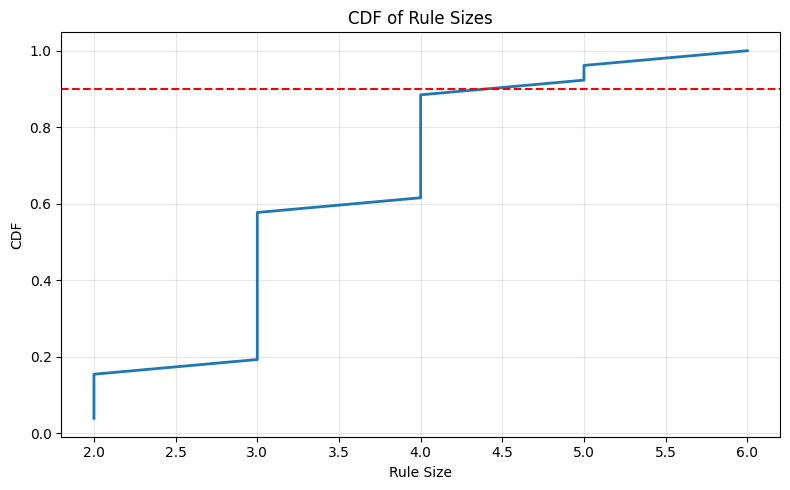

P95 Rule Size = 2.00


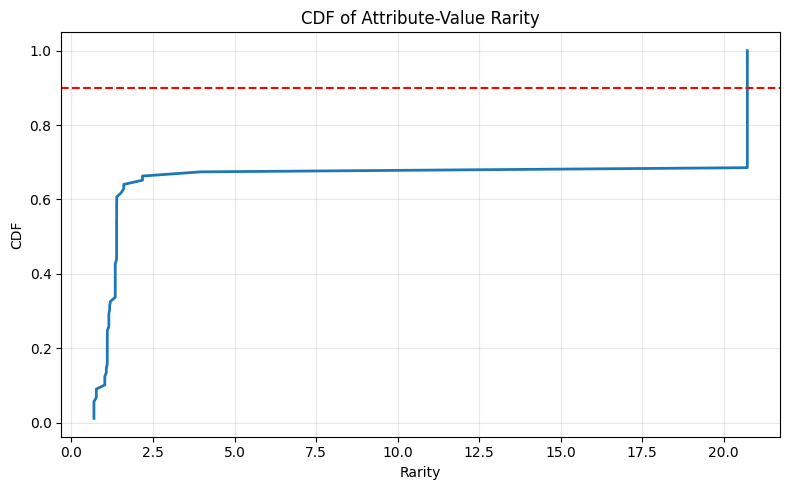

P95 Rarity = 0.6906




In [36]:
import ast
import math
import pandas as pd
import numpy as np

# ============================================================
# LOAD RULES
# ============================================================

def load_rules(file_path):

    rules = []

    with open(file_path, "r") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            data = ast.literal_eval(line)

            # only second element = rule tuples
            rule = data[1]

            # convert to tuple format
            rule = [(attr, val) for attr, val in rule]

            rules.append(rule)

    return rules


# ============================================================
# LOAD ACCESS LOG
# ============================================================

def load_dataset(dataset_path):

    df = pd.read_csv(dataset_path)

    # only granted accesses
    #df = df[df["ACTION"] == 1]

    return df


# ============================================================
# COMPUTE ATTRIBUTE-VALUE FREQUENCY
# freq(a,v) = requests containing tuple / total requests
# ============================================================

def compute_attr_val_frequency(dataset):

    total_requests = len(dataset)

    freq_lookup = {}

    for col in dataset.columns:

        if col == "ACTION":
            continue

        value_counts = dataset[col].value_counts()

        for val, count in value_counts.items():

            freq_lookup[(col, val)] = count / total_requests

    return freq_lookup


# ============================================================
# WSC
# ============================================================

def compute_wsc(rules):

    return sum(len(rule) for rule in rules)


# ============================================================
# COMPUTE POLICY COMPLEXITY C(R)
#
# C(R)= Σ |r_i|^alpha * (1 + beta * rarity(r_i))
#
# rarity(a,v) = -log(freq(a,v))
# ============================================================

def policy_complexity(rules,
                      freq_lookup,
                      alpha=2.0,
                      beta=1.0):

    total_complexity = 0

    for rule in rules:

        k = len(rule)

        rarity = 0

        for attr, val in rule:

            # avoid log(0)
            freq = freq_lookup.get((attr, val), 1e-9)

            rarity += -math.log(freq)

        rarity /= k

        score = (k ** alpha) * (1 + beta * rarity)

        total_complexity += score

    return total_complexity


# ============================================================
# MAXIMUM THEORETICAL COMPLEXITY
# ============================================================

def policy_complexity_max(rules,
                          freq_lookup,
                          alpha=2.0,
                          beta=1.0):

    n_rules = len(rules)

    # maximum rule size
    k_max = max(len(rule) for rule in rules)

    # minimum frequency observed
    min_freq = min(freq_lookup.values())

    rarity_max = -math.log(min_freq)

    c_max = (
        n_rules
        * (k_max ** alpha)
        * (1 + beta * rarity_max)
    )

    return c_max

def policy_complexity_max_2(rules,
                          freq_lookup,
                          alpha=2.0,
                          beta=1.0):

    n_rules = len(rules)

    # maximum rule size
    k_max = 12

    # minimum frequency observed
    min_freq = min(freq_lookup.values())

    rarity_max = -math.log(min_freq)

    c_max = (
        n_rules
        * (k_max ** alpha)
        * (1 + beta * rarity_max)
    )

    return c_max


# ============================================================
# NORMALIZATIONS
# ============================================================

def normalize_by_rules(CR, rules):

    return CR / len(rules)


def normalize_by_wsc(CR, rules):

    wsc = compute_wsc(rules)

    return CR / wsc


def normalize_by_cmax(CR,
                      rules,
                      freq_lookup,
                      alpha=1.5,
                      beta=1.0):

    cmax = policy_complexity_max_2(
        rules,
        freq_lookup,
        alpha,
        beta
    )

    return CR / cmax

def normalize_by_cmax_2(CR,
                      rules,
                      freq_lookup,
                      alpha=1.5,
                      beta=1.0):

    cmax = policy_complexity_max(
        rules,
        freq_lookup,
        alpha,
        beta
    )

    return CR / cmax


def get_rule_sizes_and_rarities(rules, freq_lookup):

    sizes = []
    rarities = []

    for rule in rules:

        sizes.append(len(rule))

        for attr, val in rule:

            freq = freq_lookup.get((attr, val), 1e-9)

            rarities.append(
                -math.log(freq)
            )

    return sizes, rarities

def policy_complexity_practical_max(
        rules,
        freq_lookup,
        alpha=2.0,
        beta=1.0,
        percentile=95):

    sizes, rarities = get_rule_sizes_and_rarities(
        rules,
        freq_lookup
    )

    # ----------------------------------------------------
    # Percentiles observados
    # ----------------------------------------------------

    k_practical = np.percentile(
        sizes,
        percentile
    )

    rarity_practical = np.percentile(
        rarities,
        percentile
    )

    # ----------------------------------------------------
    # Numero de reglas
    # ----------------------------------------------------

    n_rules = len(rules)

    # ----------------------------------------------------
    # Practical Maximum
    # ----------------------------------------------------

    c_practical_max = (
        n_rules
        * (k_practical ** alpha)
        * (1 + beta * rarity_practical)
    )

    return c_practical_max

def normalize_by_practical_max(
        CR,
        rules,
        freq_lookup,
        alpha=2.0,
        beta=1.0,
        percentile=95):

    practical_max = policy_complexity_practical_max(
        rules,
        freq_lookup,
        alpha,
        beta,
        percentile
    )

    return CR / practical_max


import matplotlib.pyplot as plt

def plot_rule_size_cdf(rules, th):

    sizes = [len(rule) for rule in rules]

    sizes_sorted = np.sort(sizes)

    cdf = np.arange(
        1,
        len(sizes_sorted) + 1
    ) / len(sizes_sorted)

    p95 = np.percentile(
        sizes,
        th
    )

    plt.figure(figsize=(8,5))

    plt.plot(
        sizes_sorted,
        cdf,
        linewidth=2
    )

    plt.axhline(
        th,
        linestyle='--',
        color='red'
    )

    plt.xlabel("Rule Size")
    plt.ylabel("CDF")
    plt.title("CDF of Rule Sizes")

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"P95 Rule Size = {p95:.2f}")


def plot_rarity_cdf(rules, freq_lookup, th):

    rarities = []

    for rule in rules:

        for attr, val in rule:

            freq = freq_lookup.get(
                (attr, val),
                1e-9
            )

            rarities.append(
                -np.log(freq)
            )

    rarities = np.array(rarities)

    rarities_sorted = np.sort(rarities)

    cdf = np.arange(
        1,
        len(rarities_sorted)+1
    ) / len(rarities_sorted)

    p95 = np.percentile(
        rarities,
        th
    )

    plt.figure(figsize=(8,5))

    plt.plot(
        rarities_sorted,
        cdf,
        linewidth=2
    )


    plt.axhline(
        th,
        linestyle='--',
        color='red'
    )

    plt.xlabel("Rarity")
    plt.ylabel("CDF")
    plt.title("CDF of Attribute-Value Rarity")

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"P95 Rarity = {p95:.4f}")


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # INPUT FILES
    # --------------------------------------------------------

    rules_path = "/Users/ddiaz/Documents/code/phd-thesis-lab/17_NuevoAnalisisP1/reglas_abac_karimi_iot.txt"
    dataset_path = "/Users/ddiaz/Documents/code/phd-thesis-lab/17_NuevoAnalisisP1/iot_al.csv"
    percentil = 0.90


    # --------------------------------------------------------
    # LOAD DATA
    # --------------------------------------------------------

    rules = load_rules(rules_path)

    dataset = load_dataset(dataset_path)

    # --------------------------------------------------------
    # FREQUENCIES
    # --------------------------------------------------------

    freq_lookup = compute_attr_val_frequency(dataset)

    # --------------------------------------------------------
    # PARAMETERS
    # --------------------------------------------------------

    alpha = 1.5
    beta = 1.0

    # --------------------------------------------------------
    # COMPLEXITY
    # --------------------------------------------------------

    CR = policy_complexity(
        rules,
        freq_lookup,
        alpha,
        beta
    )

    # --------------------------------------------------------
    # NORMALIZATIONS
    # --------------------------------------------------------

    CR_rules = normalize_by_rules(CR, rules)

    CR_wsc = normalize_by_wsc(CR, rules)

    CR_cmax = normalize_by_cmax(
        CR,
        rules,
        freq_lookup,
        alpha,
        beta
    )

    CR_practical = normalize_by_practical_max(
        CR,
        rules,
        freq_lookup,
        alpha,
        beta,
        percentile=90
    )

    CR_practical_95 = normalize_by_practical_max(
        CR,
        rules,
        freq_lookup,
        alpha,
        beta,
        percentile=95
    )

    CR_practical_99 = normalize_by_practical_max(
        CR,
        rules,
        freq_lookup,
        alpha,
        beta,
        percentile=99
    )

    # --------------------------------------------------------
    # WSC
    # --------------------------------------------------------

    WSC = compute_wsc(rules)

    # --------------------------------------------------------
    # RESULTS
    # --------------------------------------------------------

    print("\n==============================")
    print(" POLICY COMPLEXITY RESULTS ")
    print("==============================\n")

    print(f"|R|:                 {len(rules):.0f}")    

    print(f"WSC(R):              {WSC:.0f}")

    print(f"WSC(R) / |R|:        {WSC/len(rules):.4f}")

    print(f"C(R):                {CR:.4f}")

    print(f"C(R) / |R|:          {CR_rules:.6f}")

    print(f"C(R) / WSC(R):       {CR_wsc:.6f}")

    print(f"C(R) / C_max(R):     {CR_cmax:.6f}")

    print(
        f"C(R) / C_practical_max(R) 90: "
        f"{CR_practical:.6f}"
    )
    print(
        f"C(R) / C_practical_max(R) 95: "
        f"{CR_practical_95:.6f}"
    )
    print(
        f"C(R) / C_practical_max(R) 95: "
        f"{CR_practical_99:.6f}"
    )

    sizes, rarities = get_rule_sizes_and_rarities(
        rules,
        freq_lookup
    )

    print(
        f"k95 = {np.percentile(sizes,90):.2f}"
    )

    print(
        f"rarity95 = {np.percentile(rarities,90):.4f}"
    )

    plot_rule_size_cdf(rules, percentil)

    plot_rarity_cdf(rules, freq_lookup,percentil)
    print("\n==============================\n")